# 04 · Federated Learning: Local vs FedAvg vs Centralized

**Masalah:** setiap bank punya data sendiri yang tidak boleh dibagikan.

| Pendekatan | Data dibagikan? | Keterangan |
|---|---|---|
| **Local-only** | tidak | tiap bank melatih modelnya sendiri |
| **Federated (FedAvg)** | **tidak**, hanya bobot model | bank berkolaborasi tanpa membuka data |
| **FedProx** | tidak | FedAvg + penalti agar model lokal tidak menjauh dari global (untuk data non-IID) |
| **FedAvg + fine-tune** | tidak | model global disesuaikan sedikit ke tiap bank (personalisasi) |
| **Centralized** | **ya**, semua data digabung | tidak realistis (melanggar privasi), dipakai sebagai batas atas |

**Alur FedAvg per ronde:**
1. Server mengirim model global ke semua bank
2. Tiap bank melatih 2 epoch dengan datanya sendiri
3. Bank mengirim bobot ke server
4. Server merata-ratakan bobot (ditimbang jumlah data) → model global baru

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.precision", 3)
plt.rcParams["figure.dpi"] = 110

In [2]:
from fedprob.experiment import run_experiment_cached, method_label
from fedprob.plots import plot_fan, plot_history, plot_metric_bars, plot_reliability
from fedprob.metrics import reliability

res = run_experiment_cached("normal", cache_dir="../results")
res.summary()

,MAE,CRPS,Coverage50,Coverage80,Coverage90,Lebar80
method,,,,,,
oracle,0.285,0.162,0.424,0.724,0.844,0.778
seasonal_naive,0.417,0.237,0.536,0.828,0.926,1.457
ets,0.359,0.203,0.513,0.819,0.918,1.229
local,0.338,0.195,0.405,0.698,0.820,0.888
fedavg,0.353,0.203,0.393,0.681,0.809,0.908
fedprox,0.339,0.193,0.431,0.798,0.971,1.064
fedavg_ft,0.346,0.201,0.372,0.662,0.782,0.852
clustered,0.354,0.205,0.385,0.668,0.800,0.894
central,0.344,0.199,0.388,0.674,0.803,0.873


<Axes: title={'center': 'Loss validasi: model global per ronde (central: per epoch)'}, xlabel='ronde / epoch', ylabel='val_loss'>

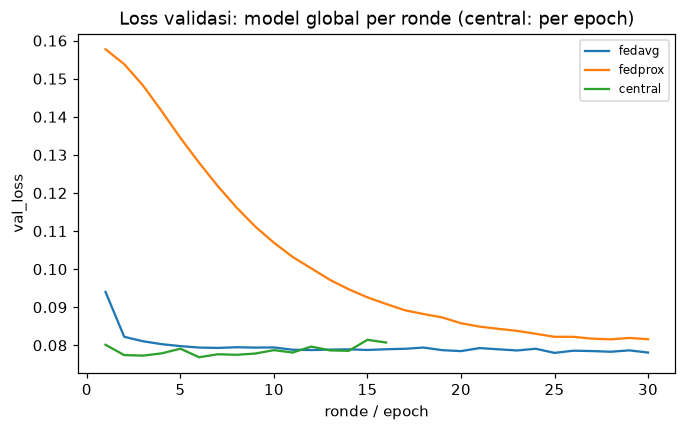

In [3]:
plot_history({k: v for k, v in res.histories.items() if k in ("fedavg", "fedprox", "central")},
             title="Loss validasi: model global per ronde (central: per epoch)")

<Axes: title={'center': 'CRPS per bank (lebih kecil lebih baik)'}>

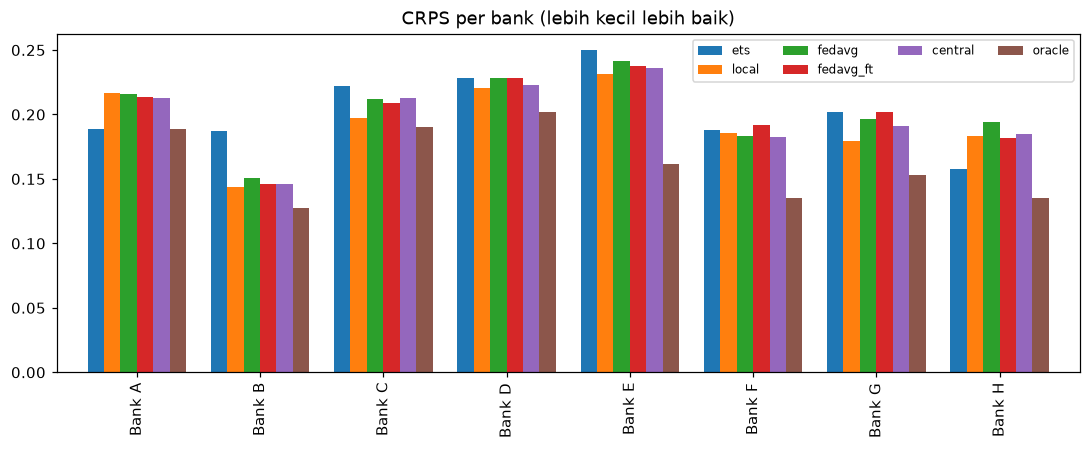

In [4]:
plot_metric_bars(res.metrics, "CRPS", methods=["ets", "local", "fedavg", "fedavg_ft", "central", "oracle"])

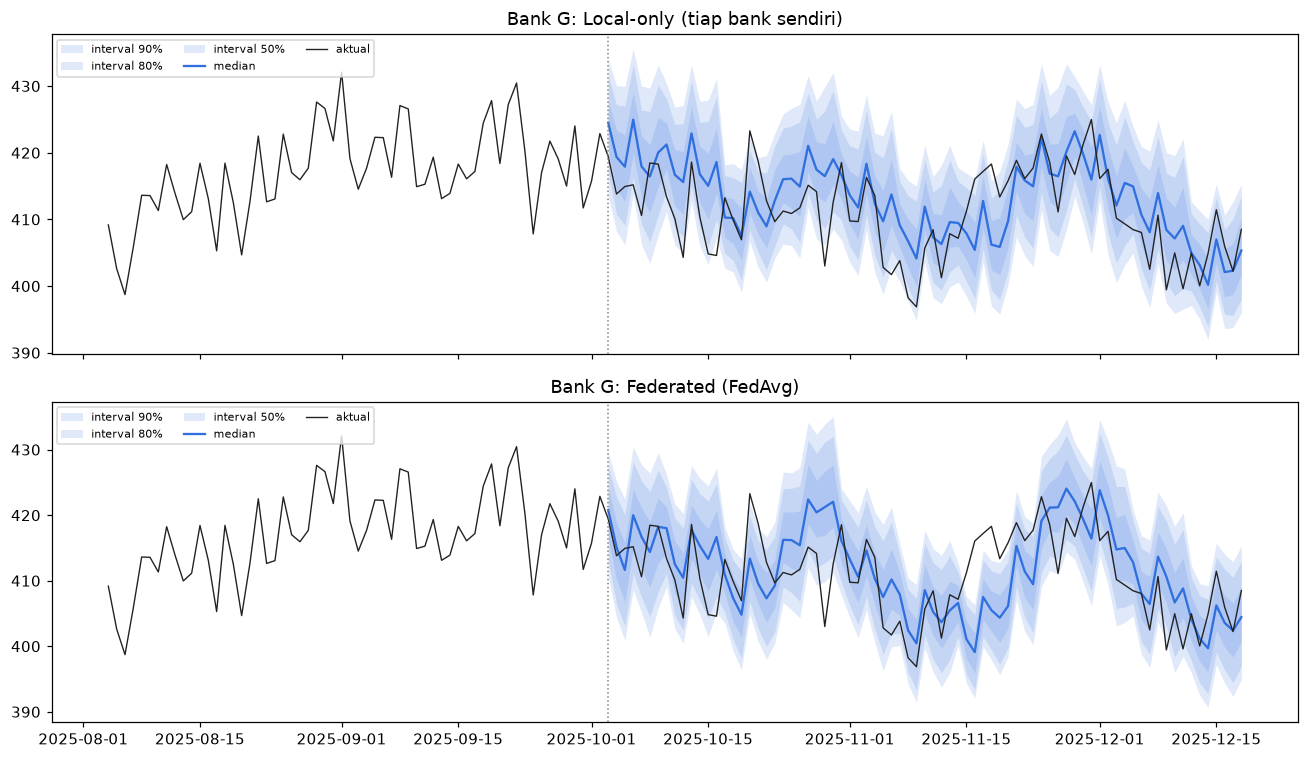

In [5]:
k = 6; c = res.clients[k]
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, m in zip(axes, ["local", "fedavg"]):
    plot_fan(res.sim, k, res.pred_original_scale(m, k), c.test.origins, ax=ax, title=f"{c.name}: {method_label(m)}")
plt.tight_layout()

<Axes: title={'center': 'Kalibrasi'}, xlabel='kuantil nominal', ylabel='proporsi aktual <= prediksi'>

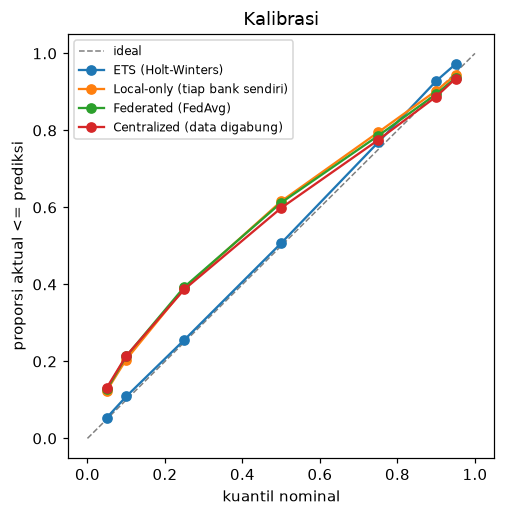

In [6]:
y = np.concatenate([c.test.y for c in res.clients])
plot_reliability({method_label(m): reliability(y, np.concatenate(res.preds[m]))
                  for m in ["ets", "local", "fedavg", "central"]})

### Cara membaca hasil
- Jika **FedAvg ≈ Centralized**, kolaborasi tanpa berbagi data hampir sebaik menggabungkan data.
- Jika **FedAvg < Local** (CRPS lebih kecil), setiap bank diuntungkan dengan berkolaborasi.
- Bandingkan coverage: apakah interval tetap "jujur" (≈ nominal)?